В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [64]:
!pip install opendatasets --upgrade --quiet

In [65]:
import types, sys
sys.modules['cgi'] = types.ModuleType('cgi')
import opendatasets as od

In [ ]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-5'
od.download(dataset_url)

In [ ]:
!pip install kaggle --quiet
!kaggle competitions download -c bank-customer-churn-prediction-dlu-course-c-5

In [56]:
import zipfile

with zipfile.ZipFile("bank-customer-churn-prediction-dlu-course-c-5.zip", "r") as zip_ref:
    zip_ref.extractall("churn_data_dlu")

In [ ]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-5'
od.download(dataset_url)

In [215]:
import os
data_dir = './churn_data_dlu'
os.listdir(data_dir)
train_csv = data_dir + '/train.csv'

In [ ]:
import pandas as pd
raw_df = pd.read_csv(train_csv)
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [72]:
input_cols = list(raw_df.columns)[1:-1]
target_col = 'Exited'

In [73]:
from sklearn.model_selection import train_test_split

In [378]:
train_inputs, val_inputs, train_targets, val_targets = train_test_split(
    raw_df[input_cols], 
    raw_df[target_col], 
    test_size = 0.2, 
    random_state=42)

train_inputs.shape, val_inputs.shape


((12000, 12), (3000, 12))

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [379]:
# Видалю CustomerId - не бачу в ній сенсу для майбутньої моделі
train_inputs = train_inputs.drop('CustomerId', axis=1)
val_inputs = val_inputs.drop('CustomerId', axis=1)

numeric_cols = train_inputs.select_dtypes(exclude='object').columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()
numeric_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Surname', 'Geography', 'Gender'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [141]:
raw_df.info()
# набір не має пропущених значень

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [180]:
for c in categorical_cols:
    print(c, raw_df[c].unique(), raw_df[c].nunique())

Surname ['Nwankwo' "Ch'in" 'Thompson' 'Macleod' 'Hsia' 'Hsieh' 'Kao' 'Hargreaves'
 'Hs?' 'Chukwuemeka' 'Hsueh' "P'an" 'Nwachukwu' 'Lucciano'
 'Ugochukwutubelum' 'Akobundu' 'Pagnotto' 'Ku' 'Lombardi' 'H?' 'Onochie'
 'Tuan' 'Chukwudi' "Ch'ang" 'McLean' 'Teng' 'Nnachetam' 'Aksakova'
 'Zetticci' 'Ndubuagha' 'Mazzanti' 'Onyemachukwu' 'Genovese' 'Ejimofor'
 'Mamelu' "Ch'ien" "Ts'ao" 'Chukwufumnanya' 'Cattaneo' 'Maclean'
 'Echezonachukwu' 'Chiang' 'Tsou' 'Biryukov' 'Chidubem' 'Fisk'
 'Chukwubuikem' 'Hsiao' "Ch'iu" 'Maughan' 'Onyinyechukwuka' 'Hsiung'
 'Macdonald' 'Aksyonova' 'Pirozzi' 'Fomin' 'Chiekwugo' 'Hirst' 'Okechukwu'
 "T'ao" 'Ross' 'Iweobiegbunam' "P'eng" 'Shih' 'Fenton' "Ch'eng" 'Lettiere'
 "T'ien" 'Yermolayev' 'Kornilova' 'Onyekachi' 'Uvarov' 'Okwukwe' 'Bogle'
 'Palerma' 'Li' 'Dike' 'Milne' 'Trevisani' 'Mironova' 'Bazarova'
 'Onwumelu' 'Chibueze' 'Uspensky' 'Milanesi' 'Palermo' 'Olisaemeka'
 'Nnamdi' 'Nkemdilim' 'Brown' 'Chiazagomekpere' 'Ritchie' 'Chin' 'Toscani'
 'Tien' 'Chinomso' 

In [380]:
# Оскільки Surname зберігає дані про прізвище клієнта, має 764 унікальні значення відповідно 
# і не має сенсу враховувати його у побудові моделі, то цю колонку можна видалити взагалі
# Geography має всього 3 можливих значення, порядок не грає ролі, тому скористаємось LabelEncoder
# Gender є бінарною колонкою, тож можна закодувати як 0 та 1

train_inputs = train_inputs.drop('Surname', axis=1)
val_inputs = val_inputs.drop('Surname', axis=1)

In [381]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

geo_encoder = OneHotEncoder(handle_unknown="ignore")

geo_encoder.fit(train_inputs[['Geography']])

encoded_cols = list(geo_encoder.get_feature_names_out(['Geography']))

train_geo_df = pd.DataFrame(
    geo_encoder.transform(train_inputs[['Geography']]).toarray(),
    columns=encoded_cols,
    index=train_inputs.index
)

val_geo_df = pd.DataFrame(
    geo_encoder.transform(val_inputs[['Geography']]).toarray(),
    columns=encoded_cols,
    index=val_inputs.index
)

train_inputs = pd.concat([train_inputs, train_geo_df], axis=1).drop('Geography', axis=1)
val_inputs   = pd.concat([val_inputs, val_geo_df], axis=1).drop('Geography', axis=1)

gen_encoder = LabelEncoder()

train_inputs.Gender = gen_encoder.fit_transform(train_inputs.Gender)
val_inputs.Gender = gen_encoder.transform(val_inputs.Gender)

In [376]:
display(train_inputs.head(), val_inputs.head())

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
9839,659.0,0,38.0,9.0,0.00,1.0,1.0,0.0,119882.70,0.0,0.0,1.0
9680,717.0,0,38.0,6.0,0.00,3.0,1.0,0.0,158973.77,1.0,0.0,0.0
7093,594.0,0,37.0,9.0,141788.63,2.0,0.0,1.0,176770.39,0.0,1.0,0.0
11293,663.0,1,52.0,1.0,108891.70,1.0,1.0,0.0,194808.51,0.0,1.0,0.0
820,629.0,1,39.0,7.0,79610.92,2.0,1.0,1.0,84760.32,0.0,1.0,0.0


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
11499,656.0,1,36.0,2.0,81370.07,2.0,0.0,1.0,116469.19,0.0,1.0,0.0
6475,602.0,1,63.0,5.0,92466.21,1.0,1.0,0.0,176913.42,1.0,0.0,0.0
13167,687.0,1,33.0,6.0,125845.66,2.0,1.0,0.0,147963.07,0.0,1.0,0.0
862,580.0,1,46.0,1.0,126576.62,1.0,0.0,0.0,172450.04,1.0,0.0,0.0
5970,683.0,0,35.0,4.0,162442.35,1.0,1.0,1.0,96498.14,0.0,0.0,1.0


In [ ]:
raw_df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.569146e+07,658.944133,37.739600,5.025267,42729.791988,1.590933,0.788800,0.489667,117784.666193,0.203467
std,4330.271354,1.352050e+05,72.255926,8.218363,2.776678,59727.309419,0.532306,0.408174,0.499910,45734.445888,0.402590
min,0.000000,1.581102e+06,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3749.750000,1.563514e+07,603.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,83058.140000,0.000000
50%,7499.500000,1.569018e+07,662.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,123584.870000,0.000000
75%,11249.250000,1.575718e+07,708.000000,42.000000,7.000000,109531.017500,2.000000,1.000000,1.000000,156884.705000,0.000000
max,14999.000000,1.581569e+07,850.000000,74.000000,10.000000,209767.310000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [382]:
# масштабуємо числові колонки, щоб мати значення в діапазоні від 0 до 1, 
# оскільки зараз дуже велика різниця у величинах

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

display(train_inputs[numeric_cols].describe(), val_inputs[numeric_cols].describe())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.545094,0.352101,0.501467,0.202051,0.197861,0.789750,0.489417,0.589492
std,0.172613,0.146487,0.278348,0.283864,0.178242,0.407503,0.499909,0.228386
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.410501,0.250000,0.300000,0.000000,0.000000,1.000000,0.000000,0.415434
50%,0.553699,0.339286,0.500000,0.000000,0.333333,1.000000,0.000000,0.617940
75%,0.663484,0.428571,0.700000,0.519112,0.333333,1.000000,1.000000,0.784649
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.539722,0.354060,0.506767,0.210300,0.193444,0.785000,0.490667,0.586640
std,0.171750,0.147843,0.274935,0.288128,0.174155,0.410891,0.499996,0.229947
min,0.007160,0.017857,0.000000,0.000000,0.000000,0.000000,0.000000,0.002181
25%,0.408115,0.250000,0.300000,0.000000,0.000000,1.000000,0.000000,0.414086
50%,0.536993,0.339286,0.500000,0.000000,0.333333,1.000000,0.000000,0.614822
75%,0.658711,0.428571,0.700000,0.530132,0.333333,1.000000,1.000000,0.783891
max,1.000000,0.964286,1.000000,0.885432,1.000000,1.000000,1.000000,1.000000


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [146]:
!pip install pyarrow --quiet

In [383]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (12000, 12)
train_targets: (12000,)
val_inputs: (3000, 12)
val_targets: (3000,)


In [384]:
train_target_df = pd.DataFrame(train_targets)
val_target_df = pd.DataFrame(val_targets)

train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
train_target_df.to_parquet('train_targets.parquet')
val_target_df.to_parquet('val_targets.parquet')

In [315]:
os.listdir('.')

['bank-customer-churn-prediction-dlu-course-c-5.zip',
 'churn_data_dlu',
 'Iryna_Konieva_HW_1_1_Основи_статистики.ipynb',
 'Iryna_Konieva_HW_2_1_Лінійна_регресія_від_багатьох_змінних.ipynb',
 'Iryna_Konieva_HW_2_1_Матриці_і_вектори_(вступ_до_лін_алгебри).ipynb',
 'Iryna_Konieva_HW_2_1_Побудова_лінійної_регресії_за_одною_ознакою.ipynb',
 'Iryna_Konieva_HW_2_1_Тестування_стат_гіпотез.ipynb',
 'Iryna_Konieva_HW_2_1_Функції_і_похідні.ipynb',
 'Iryna_Konieva_HW_2_2_Логістична_регресія_з_scikit_learn.ipynb',
 'log_reg.joblib',
 'train_inputs.parquet',
 'train_targets.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [385]:
X_train = train_inputs[['CreditScore', 'Age', 'Tenure','Balance', 'NumOfProducts', 'HasCrCard',	'IsActiveMember', 
                        'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender']]
X_val = val_inputs[['CreditScore', 'Age', 'Tenure','Balance', 'NumOfProducts', 'HasCrCard',	'IsActiveMember', 
                    'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender']]

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear')
model.fit(X_train, train_targets)

train_predicted = model.predict(X_train)
val_predicted = model.predict(X_val)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

F1 score Training: 0.62%
Confusion matrix Training:
 [[0.95948627 0.04051373]
 [0.4729674  0.5270326 ]]
F1 score Validation: 0.64%
Confusion matrix Validation:
 [[0.96119781 0.03880219]
 [0.45627981 0.54372019]]
AUROC for Training: 0.88


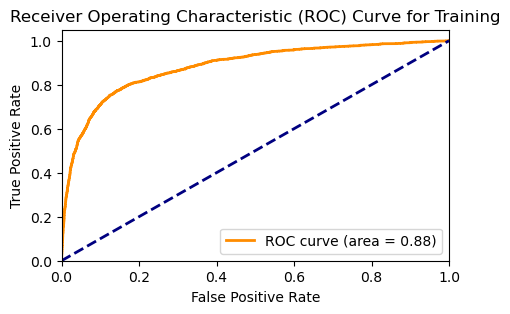

AUROC for Validation: 0.88


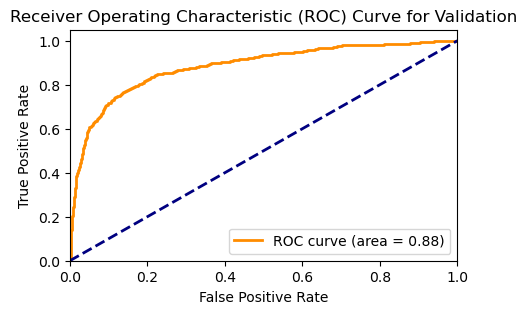

In [386]:
from sklearn.metrics import confusion_matrix, roc_curve, f1_score, auc
import matplotlib.pyplot as plt

def get_f1_cm(real, proba, name=''):
  predicted = (proba >= 0.5).astype(int)
  f1_score_ = f1_score(real, predicted)
  cm = confusion_matrix(real, predicted, normalize='true')
  # TN FP
  # FN TP
  print(f"F1 score {name}: {f1_score_:.2f}%")
  print(f"Confusion matrix {name}:\n {cm}")

train_proba = model.predict_proba(X_train)[:, 1]
val_proba   = model.predict_proba(X_val)[:, 1]

get_f1_cm(train_targets, train_proba, 'Training')
get_f1_cm(val_targets, val_proba, 'Validation')

def compute_auroc_and_build_roc(inputs, targets, name=''):
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  plt.figure(figsize=(5,3))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

Модель не погана загалом, можна краще. F1 (0.58 та 0.56) нормальний для бейзлайна. Confusion matrix показала, що модель добре передбачає True-Negative, що є логічним, бо ми маємо найбільше даних з показником 0, а 1 - аномалія, яку треба визначати - досить низький і треба покращувати. AUROC більше 0.8, тож модель добре відділяє позитивні і негативні

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [387]:
import numpy as np
from sklearn.metrics import accuracy_score

def all_no(inputs):
    return np.full(len(inputs), 0)

print(f"FITTED\nAccuracy score Train: {accuracy_score(train_targets,train_predicted):.2f}%")
print(f"Accuracy score Validate: {accuracy_score(val_targets,val_predicted):.2f}%")
print(f"ALL NO\nAccuracy score Train: {accuracy_score(train_targets,all_no(train_inputs)):.2f}%")
print(f"Accuracy score Validate: {accuracy_score(val_targets,all_no(val_inputs)):.2f}%")

FITTED
Accuracy score Train: 0.87%
Accuracy score Validate: 0.87%
ALL NO
Accuracy score Train: 0.80%
Accuracy score Validate: 0.79%


Якість моделі - задовільна. Accuracy передбачення трохи більша для створеної моделі, ніж для випадку, коли всі дані = 0.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [388]:
import joblib

churn_data = {
    'model': model,
    'scaler': scaler,
    'label_encoder_geo': geo_encoder,
    'label_encoder_gen': gen_encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols
}

joblib.dump(churn_data, 'log_reg.joblib')

model_2 = joblib.load('log_reg.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoders, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    geo_encoded = encoders[0].transform(input_df[['Geography']]).toarray()
    geo_cols = encoders[0].get_feature_names_out(['Geography'])
    geo_df = pd.DataFrame(geo_encoded, columns=geo_cols, index=input_df.index)
    
    input_df['Gender'] = encoders[1].transform(input_df['Gender'])
    
    X_input = pd.concat([input_df[numeric_cols], geo_df, input_df[['Gender']]], axis=1)
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [393]:
predict_raw_df(scaler, [geo_encoder,gen_encoder], numeric_cols, categorical_cols, raw_df[:5])

array([0.00709438, 0.03627904, 0.36702742, 0.38633732, 0.97330984])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [401]:
test_raw_df = pd.read_csv('churn_data_dlu/test.csv')

In [ ]:
test_raw_df['Exited'] = predict_raw_df(scaler, [geo_encoder,gen_encoder], numeric_cols, categorical_cols, test_raw_df)
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,0.365155,Germany,1,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,0.074333
1,15001,15642821.0,Mazzi,0.286396,France,1,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,0.032874
2,15002,15716284.0,Onyekachi,0.656325,France,1,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,0.154175
3,15003,15785078.0,Martin,0.682578,Spain,1,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.194115
4,15004,15662955.0,Kenechukwu,0.384248,Spain,1,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.052479
5,15005,15759066.0,Genovesi,0.429594,France,1,0.321429,0.7,0.294666,0.000000,1.0,0.0,0.728994,0.167452
6,15006,15754926.0,Haddon,0.603819,France,0,0.321429,0.0,0.000000,0.333333,1.0,0.0,0.808375,0.146422
7,15007,15664802.0,Chiang,0.374702,France,1,0.375000,0.4,0.000000,0.333333,0.0,0.0,0.289284,0.121104
8,15008,15757537.0,Iweobiegbulam,0.431981,Germany,1,0.160714,0.3,0.740883,0.333333,1.0,0.0,0.700844,0.043488
9,15009,15674928.0,Hoolan,0.727924,France,0,0.250000,0.8,0.000000,0.333333,1.0,0.0,0.379824,0.066948


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [409]:
submission_raw_df = pd.read_csv('churn_data_dlu/sample_submission.csv')

submission_raw_df['Exited'] = test_raw_df.Exited.apply(lambda x: 1 if x>0.5 else 0)
submission_raw_df.head()

submission_raw_df.to_csv("submission_log_reg.csv", index=False)